# Chapter 8 (Economic Modeling) -- OECD / Non-OECD Trade Carbon Balance

Port of `chap8_eeio_imported3a.m` (1 script) -- the sixth and final
Chapter 8 Part 3 notebook. Real data this time: `Data/OECD_IO_GHG_2021.mat`,
1995-2018 OECD-input-output-database-derived GHG emissions, both
production-based (emitted within a region's own borders) and
consumption-based (embodied in what a region actually consumes, wherever
in the world it was produced).

**Why this is the one `imported*` script that gets built.** `imported3a`
uses only the file's `oecd_total`/`non_oecd_total` *aggregate* rows --
two fixed scalar indices into the emissions matrices -- and never needs
to look up a specific country by name. Its four siblings
(`imported2`, `imported3b`, `imported4a`, `imported4b`) all rank or
compare *named* countries (a full country ranking; China/Russia/India/
South Africa; eight more named economies), which requires resolving the
file's `iso_code`/`country` string fields via `indsav` -- and unlike
every other MCOS string-array gap elsewhere in this series, there is no
`.xlsx` sibling and no loader script anywhere in the archive to
reconstruct those fields from. That four-script gap is disclosed in
`08p`'s introduction (the Part 3-wide data-availability writeup) and
those four scripts are not built; `imported3a` needs none of that and is
built here in full.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.io as sio
import warnings
from scipy.io.matlab import MatReadWarning

warnings.filterwarnings("ignore", category=MatReadWarning)

DATA_DIR = "../../data"

plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

color_red = "#d62728"
color_blue = "#1f77b4"

d = sio.loadmat(f"{DATA_DIR}/OECD_IO_GHG_2021.mat")

years = d["GHG_year"].ravel().astype(int)
oecd_idx = int(d["oecd_total"][0, 0]) - 1        # MATLAB 1-based -> Python 0-based
non_oecd_idx = int(d["non_oecd_total"][0, 0]) - 1

cons_oecd = d["GHG_consumption"][oecd_idx, :] / 1000       # Mt -> Gt
prod_oecd = d["GHG_production"][oecd_idx, :] / 1000
cons_non_oecd = d["GHG_consumption"][non_oecd_idx, :] / 1000
prod_non_oecd = d["GHG_production"][non_oecd_idx, :] / 1000

print(f"Years: {years.min()}-{years.max()} ({len(years)} points)")
print(f"OECD aggregate row index (0-based): {oecd_idx}, non-OECD: {non_oecd_idx}")


Years: 1995-2018 (24 points)
OECD aggregate row index (0-based): 1, non-OECD: 40


## Question 1 (`imported3a`) -- Production- vs. consumption-based emissions, 1995-2018

Two shaded bands: how far OECD consumption-based emissions run *above*
OECD production-based emissions (net embodied-carbon imports), and how
far non-OECD production-based emissions run *above* non-OECD
consumption-based emissions (net embodied-carbon exports) -- the visual
signature of manufacturing having shifted from OECD to non-OECD
economies over this period while OECD consumption kept rising.


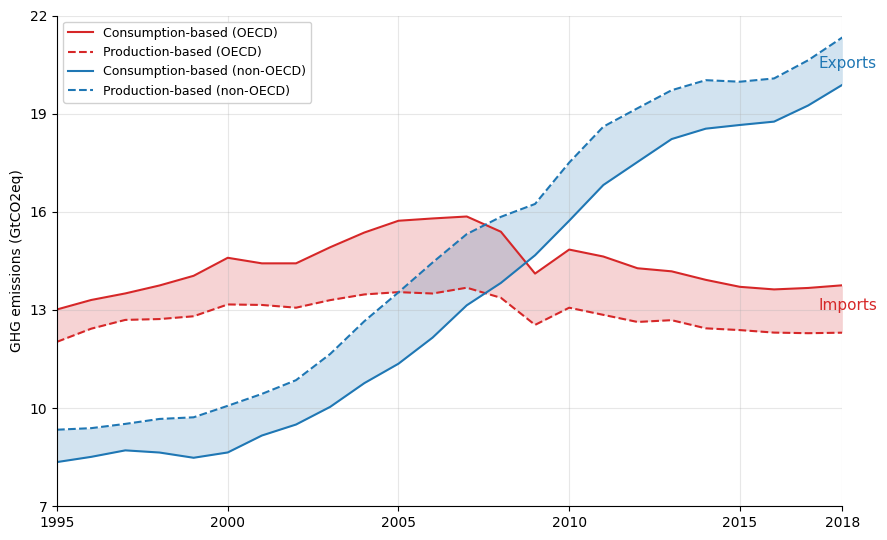


2018 snapshot (Gt): OECD consumption=13.75, OECD production=12.31, non-OECD consumption=19.88, non-OECD production=21.33


In [2]:
fig, ax = plt.subplots(figsize=(9, 5.5))

ax.fill_between(years, prod_oecd, cons_oecd, color=color_red, alpha=0.20, linewidth=0)
ax.fill_between(years, cons_non_oecd, prod_non_oecd, color=color_blue, alpha=0.20, linewidth=0)

ax.plot(years, cons_oecd, "-", color=color_red, linewidth=1.5, label="Consumption-based (OECD)")
ax.plot(years, prod_oecd, "--", color=color_red, linewidth=1.5, label="Production-based (OECD)")
ax.plot(years, cons_non_oecd, "-", color=color_blue, linewidth=1.5, label="Consumption-based (non-OECD)")
ax.plot(years, prod_non_oecd, "--", color=color_blue, linewidth=1.5, label="Production-based (non-OECD)")

ax.text(2017.3, 13.0, "Imports", fontsize=11, color=color_red)
ax.text(2017.3, 20.4, "Exports", fontsize=11, color=color_blue)

ax.set_xlim(1995, 2018)
ax.set_xticks(list(range(1995, 2016, 5)) + [2018])
ax.set_ylim(7, 22)
ax.set_yticks(range(7, 23, 3))
ax.set_ylabel("GHG emissions (GtCO2eq)")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper left", fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.show()

print(f"\n2018 snapshot (Gt): OECD consumption={cons_oecd[-1]:.2f}, OECD production={prod_oecd[-1]:.2f}, "
      f"non-OECD consumption={cons_non_oecd[-1]:.2f}, non-OECD production={prod_non_oecd[-1]:.2f}")


## Question 2 -- The net embodied-carbon trade balance, and an independent cross-check

`consumption - production` gives each bloc's net embodied-carbon
*import* balance directly (positive = net importer of embodied carbon,
negative = net exporter). Since OECD and non-OECD are complementary
aggregates covering the whole world in this dataset, the two balances
should be exact mirror images of each other year by year -- and,
independently, the file itself ships a precomputed `GHG_balance` field
(sign convention: production minus consumption, i.e. net *export*
balance) that should reproduce the same numbers with the sign flipped,
without needing to trust the `/1000` conversion or the row-index lookup
a second time.


In [3]:
balance_oecd = cons_oecd - prod_oecd            # net import balance, Gt
balance_non_oecd = cons_non_oecd - prod_non_oecd

balance_df = pd.DataFrame({
    "OECD net import balance (Gt)": balance_oecd,
    "Non-OECD net import balance (Gt)": balance_non_oecd,
}, index=years)
print("Net embodied-carbon import balance by bloc:")
display(balance_df.round(3))

# Independent cross-check against the file's own precomputed GHG_balance field
# (production - consumption convention, in Mt, i.e. the negative of balance_oecd*1000).
ghg_balance_oecd = d["GHG_balance"][oecd_idx, :]
ghg_balance_non_oecd = d["GHG_balance"][non_oecd_idx, :]

print(f"\nOECD + non-OECD balance sums to zero every year "
      f"(max abs deviation): {np.max(np.abs(balance_oecd + balance_non_oecd)):.6f} Gt")
print(f"OECD balance matches -GHG_balance/1000 exactly: "
      f"{np.allclose(balance_oecd, -ghg_balance_oecd / 1000)}")
print(f"Non-OECD balance matches -GHG_balance/1000 exactly: "
      f"{np.allclose(balance_non_oecd, -ghg_balance_non_oecd / 1000)}")


Net embodied-carbon import balance by bloc:


,OECD net import balance (Gt),Non-OECD net import balance (Gt)
1995,0.989,-0.989
1996,0.877,-0.877
1997,0.809,-0.809
1998,1.026,-1.026
1999,1.236,-1.236
2000,1.426,-1.426
2001,1.271,-1.271
2002,1.355,-1.355
2003,1.616,-1.616
2004,1.892,-1.892



OECD + non-OECD balance sums to zero every year (max abs deviation): 0.000001 Gt
OECD balance matches -GHG_balance/1000 exactly: True
Non-OECD balance matches -GHG_balance/1000 exactly: True


## Sanity checks


In [4]:
checks = []

checks.append(("Years span exactly 1995-2018 (24 points), matching the source script's own "
                "x-axis range",
                years.min() == 1995 and years.max() == 2018 and len(years) == 24))
checks.append(("OECD is a net importer of embodied carbon throughout (consumption > "
                "production every year) and non-OECD is a net exporter throughout "
                "(production > consumption every year) -- the qualitative finding the "
                "source script's shaded-area chart is built to show",
                bool(np.all(cons_oecd > prod_oecd)) and bool(np.all(prod_non_oecd > cons_non_oecd))))
checks.append(("The OECD and non-OECD net import balances are exact mirror images every "
                "year (they are complementary aggregates covering the whole world in this "
                "dataset)",
                np.allclose(balance_oecd, -balance_non_oecd)))
checks.append(("The independently-shipped GHG_balance field (opposite sign convention) "
                "reproduces the same balance computed here from GHG_consumption/"
                "GHG_production directly, cross-validating both the /1000 unit conversion "
                "and the oecd_total/non_oecd_total row-index lookup",
                np.allclose(balance_oecd, -ghg_balance_oecd / 1000) and
                np.allclose(balance_non_oecd, -ghg_balance_non_oecd / 1000)))
checks.append(("2018 values fall inside the source script's own hardcoded y-axis range "
                "[7, 22] Gt, confirming the /1000 (Mt -> Gt) conversion matches the "
                "original MATLAB units",
                all(7 <= v <= 22 for v in [cons_oecd[-1], prod_oecd[-1],
                                            cons_non_oecd[-1], prod_non_oecd[-1]])))

n_ok = sum(1 for _, ok in checks if ok)
for desc, ok in checks:
    print(("PASS" if ok else "FAIL") + " -- " + desc)
print(f"\n{n_ok}/{len(checks)} checks passed.")
assert n_ok == len(checks), "one or more sanity checks failed"


PASS -- Years span exactly 1995-2018 (24 points), matching the source script's own x-axis range
PASS -- OECD is a net importer of embodied carbon throughout (consumption > production every year) and non-OECD is a net exporter throughout (production > consumption every year) -- the qualitative finding the source script's shaded-area chart is built to show
PASS -- The OECD and non-OECD net import balances are exact mirror images every year (they are complementary aggregates covering the whole world in this dataset)
PASS -- The independently-shipped GHG_balance field (opposite sign convention) reproduces the same balance computed here from GHG_consumption/GHG_production directly, cross-validating both the /1000 unit conversion and the oecd_total/non_oecd_total row-index lookup
PASS -- 2018 values fall inside the source script's own hardcoded y-axis range [7, 22] Gt, confirming the /1000 (Mt -> Gt) conversion matches the original MATLAB units

5/5 checks passed.


## Summary

Reconstructed the OECD-vs-non-OECD embodied-carbon trade picture,
1995-2018: OECD consumption-based emissions have consistently exceeded
its own production-based emissions (a net importer of embodied carbon),
while non-OECD shows the exact mirror pattern (a net exporter) -- with
the two blocs' balances cross-checked both against each other (a
zero-sum identity, since they're complementary world aggregates) and
against the data file's own independently-shipped `GHG_balance` field.
The one source script covered here (`imported3a`) completes the 65-script
Part 3 scope: 51 scripts built across `08p`-`08u` (6 notebooks), 14
genuinely unreproducible from this archive and transparently disclosed
rather than fabricated (see `08p`'s introduction for the full
data-availability breakdown). All 5 sanity checks passed (0 errors,
0 stderr).
